# Testando um modelo simples de aprendizado de um Datase aleatório

## Imports

In [3]:
import IPython.display as ipd
import json
import numpy as np
import matplotlib.pyplot as plt
import random
import soundfile as sf
import pandas as pd

from fm_synth import FMSynth, SAMPLE_RATE


## Carregando o dataset

In [4]:
tamanho_dataset = 1000

In [5]:
samples = []
for i in range(tamanho_dataset):
    signal = sf.read(f"dataset/sample_{i}.wav")
    samples.append(signal)

samples = pd.DataFrame(samples)

In [6]:
samples = samples.drop(columns=[1])
samples.head()

,0
0,"[0.0, -0.000823974609375, -0.001495361328125, ..."
1,"[0.0, 6.103515625e-05, -0.000335693359375, 0.0..."
2,"[0.0, -0.000640869140625, -0.00189208984375, 0..."
3,"[0.0, 0.000518798828125, -0.000762939453125, -..."
4,"[0.0, 0.00018310546875, 0.0003662109375, 3.051..."


### Lendo o alvo

In [7]:
with open("dataset/parameters.json", "r") as f:
    target = f.read()

target = json.loads(target)
target = target[:tamanho_dataset]

target = pd.DataFrame(target)
target.head()

,id,frequencia_base,amplitude1,frequency1,beta2,amplitude2,frequency2,beta3,amplitude3,frequency3,...,frequency4,beta5,amplitude5,frequency5,beta_carrier,amplitude_carrier,attack,decay,sustain,release
0,0,18209.492,0.364,0.490,0.204,0.192,0.715,0.384,0.289,0.087,...,0.410,0.173,0.568,0.360,0.118,0.308,0.015,0.023,0.013,0.021
1,1,9383.727,0.441,0.797,0.376,0.110,0.907,0.510,0.544,0.366,...,0.317,0.147,0.074,0.999,0.852,0.189,0.046,0.072,0.078,0.050
2,2,17779.337,0.845,0.884,0.549,0.063,0.866,0.798,0.834,0.928,...,0.475,0.229,0.950,0.256,0.624,0.117,0.005,0.006,0.022,0.121
3,3,6646.624,0.714,0.934,0.246,0.036,0.556,0.652,0.534,0.779,...,0.576,0.739,0.418,0.075,0.540,0.970,0.078,0.040,0.475,0.059
4,4,3602.038,0.103,0.625,0.311,0.795,0.871,0.143,0.270,0.333,...,0.128,0.131,0.011,0.994,0.342,0.331,0.067,0.040,0.458,0.105


In [8]:
target = target.drop(columns=["id"])
target.head()

,frequencia_base,amplitude1,frequency1,beta2,amplitude2,frequency2,beta3,amplitude3,frequency3,beta4,...,frequency4,beta5,amplitude5,frequency5,beta_carrier,amplitude_carrier,attack,decay,sustain,release
0,18209.492,0.364,0.490,0.204,0.192,0.715,0.384,0.289,0.087,0.645,...,0.410,0.173,0.568,0.360,0.118,0.308,0.015,0.023,0.013,0.021
1,9383.727,0.441,0.797,0.376,0.110,0.907,0.510,0.544,0.366,0.936,...,0.317,0.147,0.074,0.999,0.852,0.189,0.046,0.072,0.078,0.050
2,17779.337,0.845,0.884,0.549,0.063,0.866,0.798,0.834,0.928,0.830,...,0.475,0.229,0.950,0.256,0.624,0.117,0.005,0.006,0.022,0.121
3,6646.624,0.714,0.934,0.246,0.036,0.556,0.652,0.534,0.779,0.802,...,0.576,0.739,0.418,0.075,0.540,0.970,0.078,0.040,0.475,0.059
4,3602.038,0.103,0.625,0.311,0.795,0.871,0.143,0.270,0.333,0.739,...,0.128,0.131,0.011,0.994,0.342,0.331,0.067,0.040,0.458,0.105


### Juntando alvo e features

In [9]:
ds = pd.concat([samples, target], axis=1)
ds.head()

,0,frequencia_base,amplitude1,frequency1,beta2,amplitude2,frequency2,beta3,amplitude3,frequency3,...,frequency4,beta5,amplitude5,frequency5,beta_carrier,amplitude_carrier,attack,decay,sustain,release
0,"[0.0, -0.000823974609375, -0.001495361328125, ...",18209.492,0.364,0.490,0.204,0.192,0.715,0.384,0.289,0.087,...,0.410,0.173,0.568,0.360,0.118,0.308,0.015,0.023,0.013,0.021
1,"[0.0, 6.103515625e-05, -0.000335693359375, 0.0...",9383.727,0.441,0.797,0.376,0.110,0.907,0.510,0.544,0.366,...,0.317,0.147,0.074,0.999,0.852,0.189,0.046,0.072,0.078,0.050
2,"[0.0, -0.000640869140625, -0.00189208984375, 0...",17779.337,0.845,0.884,0.549,0.063,0.866,0.798,0.834,0.928,...,0.475,0.229,0.950,0.256,0.624,0.117,0.005,0.006,0.022,0.121
3,"[0.0, 0.000518798828125, -0.000762939453125, -...",6646.624,0.714,0.934,0.246,0.036,0.556,0.652,0.534,0.779,...,0.576,0.739,0.418,0.075,0.540,0.970,0.078,0.040,0.475,0.059
4,"[0.0, 0.00018310546875, 0.0003662109375, 3.051...",3602.038,0.103,0.625,0.311,0.795,0.871,0.143,0.270,0.333,...,0.128,0.131,0.011,0.994,0.342,0.331,0.067,0.040,0.458,0.105


In [10]:
ds.shape

(1000, 22)

## Separando treino e teste

In [11]:
train = ds.sample(frac=0.75, random_state=0)
test = ds.drop(train.index)

In [12]:
train.head(5)

,0,frequencia_base,amplitude1,frequency1,beta2,amplitude2,frequency2,beta3,amplitude3,frequency3,...,frequency4,beta5,amplitude5,frequency5,beta_carrier,amplitude_carrier,attack,decay,sustain,release
993,"[0.0, -0.000152587890625, -0.00042724609375, -...",19347.502,0.580,0.677,0.172,0.176,0.026,0.518,0.142,0.155,...,0.310,0.600,0.313,0.490,0.536,0.853,0.188,0.023,0.121,0.130
859,"[0.0, -0.00030517578125, -0.000732421875, -0.0...",18729.342,0.206,0.422,0.799,0.796,0.455,0.762,0.821,0.160,...,0.258,0.299,0.578,0.437,0.061,0.635,0.076,0.024,0.354,0.189
298,"[0.0, -0.00067138671875, -0.000823974609375, 0...",17795.401,0.924,0.533,0.282,0.289,0.690,0.622,0.788,0.792,...,0.041,0.620,0.728,0.420,0.194,0.808,0.049,0.080,0.236,0.150
553,"[0.0, -3.0517578125e-05, -6.103515625e-05, -3....",18426.567,0.897,0.285,0.550,0.808,0.440,0.526,0.513,0.681,...,0.663,0.883,0.495,0.430,0.790,0.125,0.127,0.073,0.341,0.069
672,"[0.0, 0.0, 3.0517578125e-05, 3.0517578125e-05,...",2052.557,0.004,0.545,0.949,0.711,0.755,0.662,0.562,0.722,...,0.179,0.013,0.815,0.154,0.925,0.023,0.062,0.056,0.161,0.193


In [13]:
x = pd.DataFrame(train[0])
x.head()

,0
993,"[0.0, -0.000152587890625, -0.00042724609375, -..."
859,"[0.0, -0.00030517578125, -0.000732421875, -0.0..."
298,"[0.0, -0.00067138671875, -0.000823974609375, 0..."
553,"[0.0, -3.0517578125e-05, -6.103515625e-05, -3...."
672,"[0.0, 0.0, 3.0517578125e-05, 3.0517578125e-05,..."


In [14]:
x = np.array(x[0].values.tolist())
x[0]

array([ 0.00000000e+00, -1.52587891e-04, -4.27246094e-04, ...,
       -9.15527344e-05, -9.15527344e-05, -3.05175781e-05])

In [15]:
len(x[0])

22050

In [16]:
y = train.drop(columns=[0])
y.head()

,frequencia_base,amplitude1,frequency1,beta2,amplitude2,frequency2,beta3,amplitude3,frequency3,beta4,...,frequency4,beta5,amplitude5,frequency5,beta_carrier,amplitude_carrier,attack,decay,sustain,release
993,19347.502,0.580,0.677,0.172,0.176,0.026,0.518,0.142,0.155,0.811,...,0.310,0.600,0.313,0.490,0.536,0.853,0.188,0.023,0.121,0.130
859,18729.342,0.206,0.422,0.799,0.796,0.455,0.762,0.821,0.160,0.064,...,0.258,0.299,0.578,0.437,0.061,0.635,0.076,0.024,0.354,0.189
298,17795.401,0.924,0.533,0.282,0.289,0.690,0.622,0.788,0.792,0.111,...,0.041,0.620,0.728,0.420,0.194,0.808,0.049,0.080,0.236,0.150
553,18426.567,0.897,0.285,0.550,0.808,0.440,0.526,0.513,0.681,0.439,...,0.663,0.883,0.495,0.430,0.790,0.125,0.127,0.073,0.341,0.069
672,2052.557,0.004,0.545,0.949,0.711,0.755,0.662,0.562,0.722,0.950,...,0.179,0.013,0.815,0.154,0.925,0.023,0.062,0.056,0.161,0.193


In [17]:
from sklearn.preprocessing import StandardScaler
scaler_y = StandardScaler()
y_train_norm = scaler_y.fit_transform(y)
print(y_train_norm)

[[ 1.55769312  0.24406094  0.65910292 ... -0.93992134 -0.88790927
   0.57783482]
 [ 1.45289775 -1.05873069 -0.2290101  ... -0.90592042  0.71938899
   1.60092983]
 [ 1.29456868  1.44235057  0.15758027 ...  0.99813091 -0.09460755
   0.92464669]
 ...
 [-0.39493883  0.39384715  1.01086533 ... -1.55193784 -0.54989375
  -0.68802851]
 [ 0.0523075   1.13581136  0.53023946 ...  0.86212724  0.00886658
   1.06337143]
 [-0.30275345 -1.6509087  -1.41316079 ...  0.89612816  0.41586486
   0.0922982 ]]


### Redimensionando a entrada

In [18]:
print(x.shape)
x = x.reshape((x.shape[0], x.shape[1], 1))
print(x.shape)

print(x[0])

# frame_length = 2048

# dataset = []
# for sample in x:
#   length = sample.shape[0]
#   num_frames = int(length / frame_length)
#   amostras_uteis = num_frames * frame_length
#   sample_cutted = sample[:amostras_uteis]
#   sample_cutted = sample_cutted.reshape(num_frames, frame_length)
#   dataset.append(sample_cutted)

# x = np.array(dataset)
# print(x.shape)
# x[0:5]

(750, 22050)
(750, 22050, 1)
[[ 0.00000000e+00]
 [-1.52587891e-04]
 [-4.27246094e-04]
 ...
 [-9.15527344e-05]
 [-9.15527344e-05]
 [-3.05175781e-05]]


## Construindo o modelo

In [19]:
from keras.layers import TimeDistributed, Dense, Input, Lambda, BatchNormalization, Concatenate, Conv1D, ZeroPadding1D, Flatten, Dropout, MaxPooling1D, GlobalAveragePooling1D
from keras.models import Model
from tensorflow.keras.utils import plot_model
from keras.callbacks import EarlyStopping
import tensorflow as tf

2025-02-26 22:10:26.583686: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-02-26 22:10:26.723508: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1740618626.787202    5161 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1740618626.803301    5161 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-02-26 22:10:26.933764: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instr

In [20]:
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

Num GPUs Available:  1


In [21]:
# Configurando para não alocar diretamente toda a memória da GPU (alocar conforme necessário)
gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)  # Aloca memória conforme necessário
    except RuntimeError as e:
        print(e)

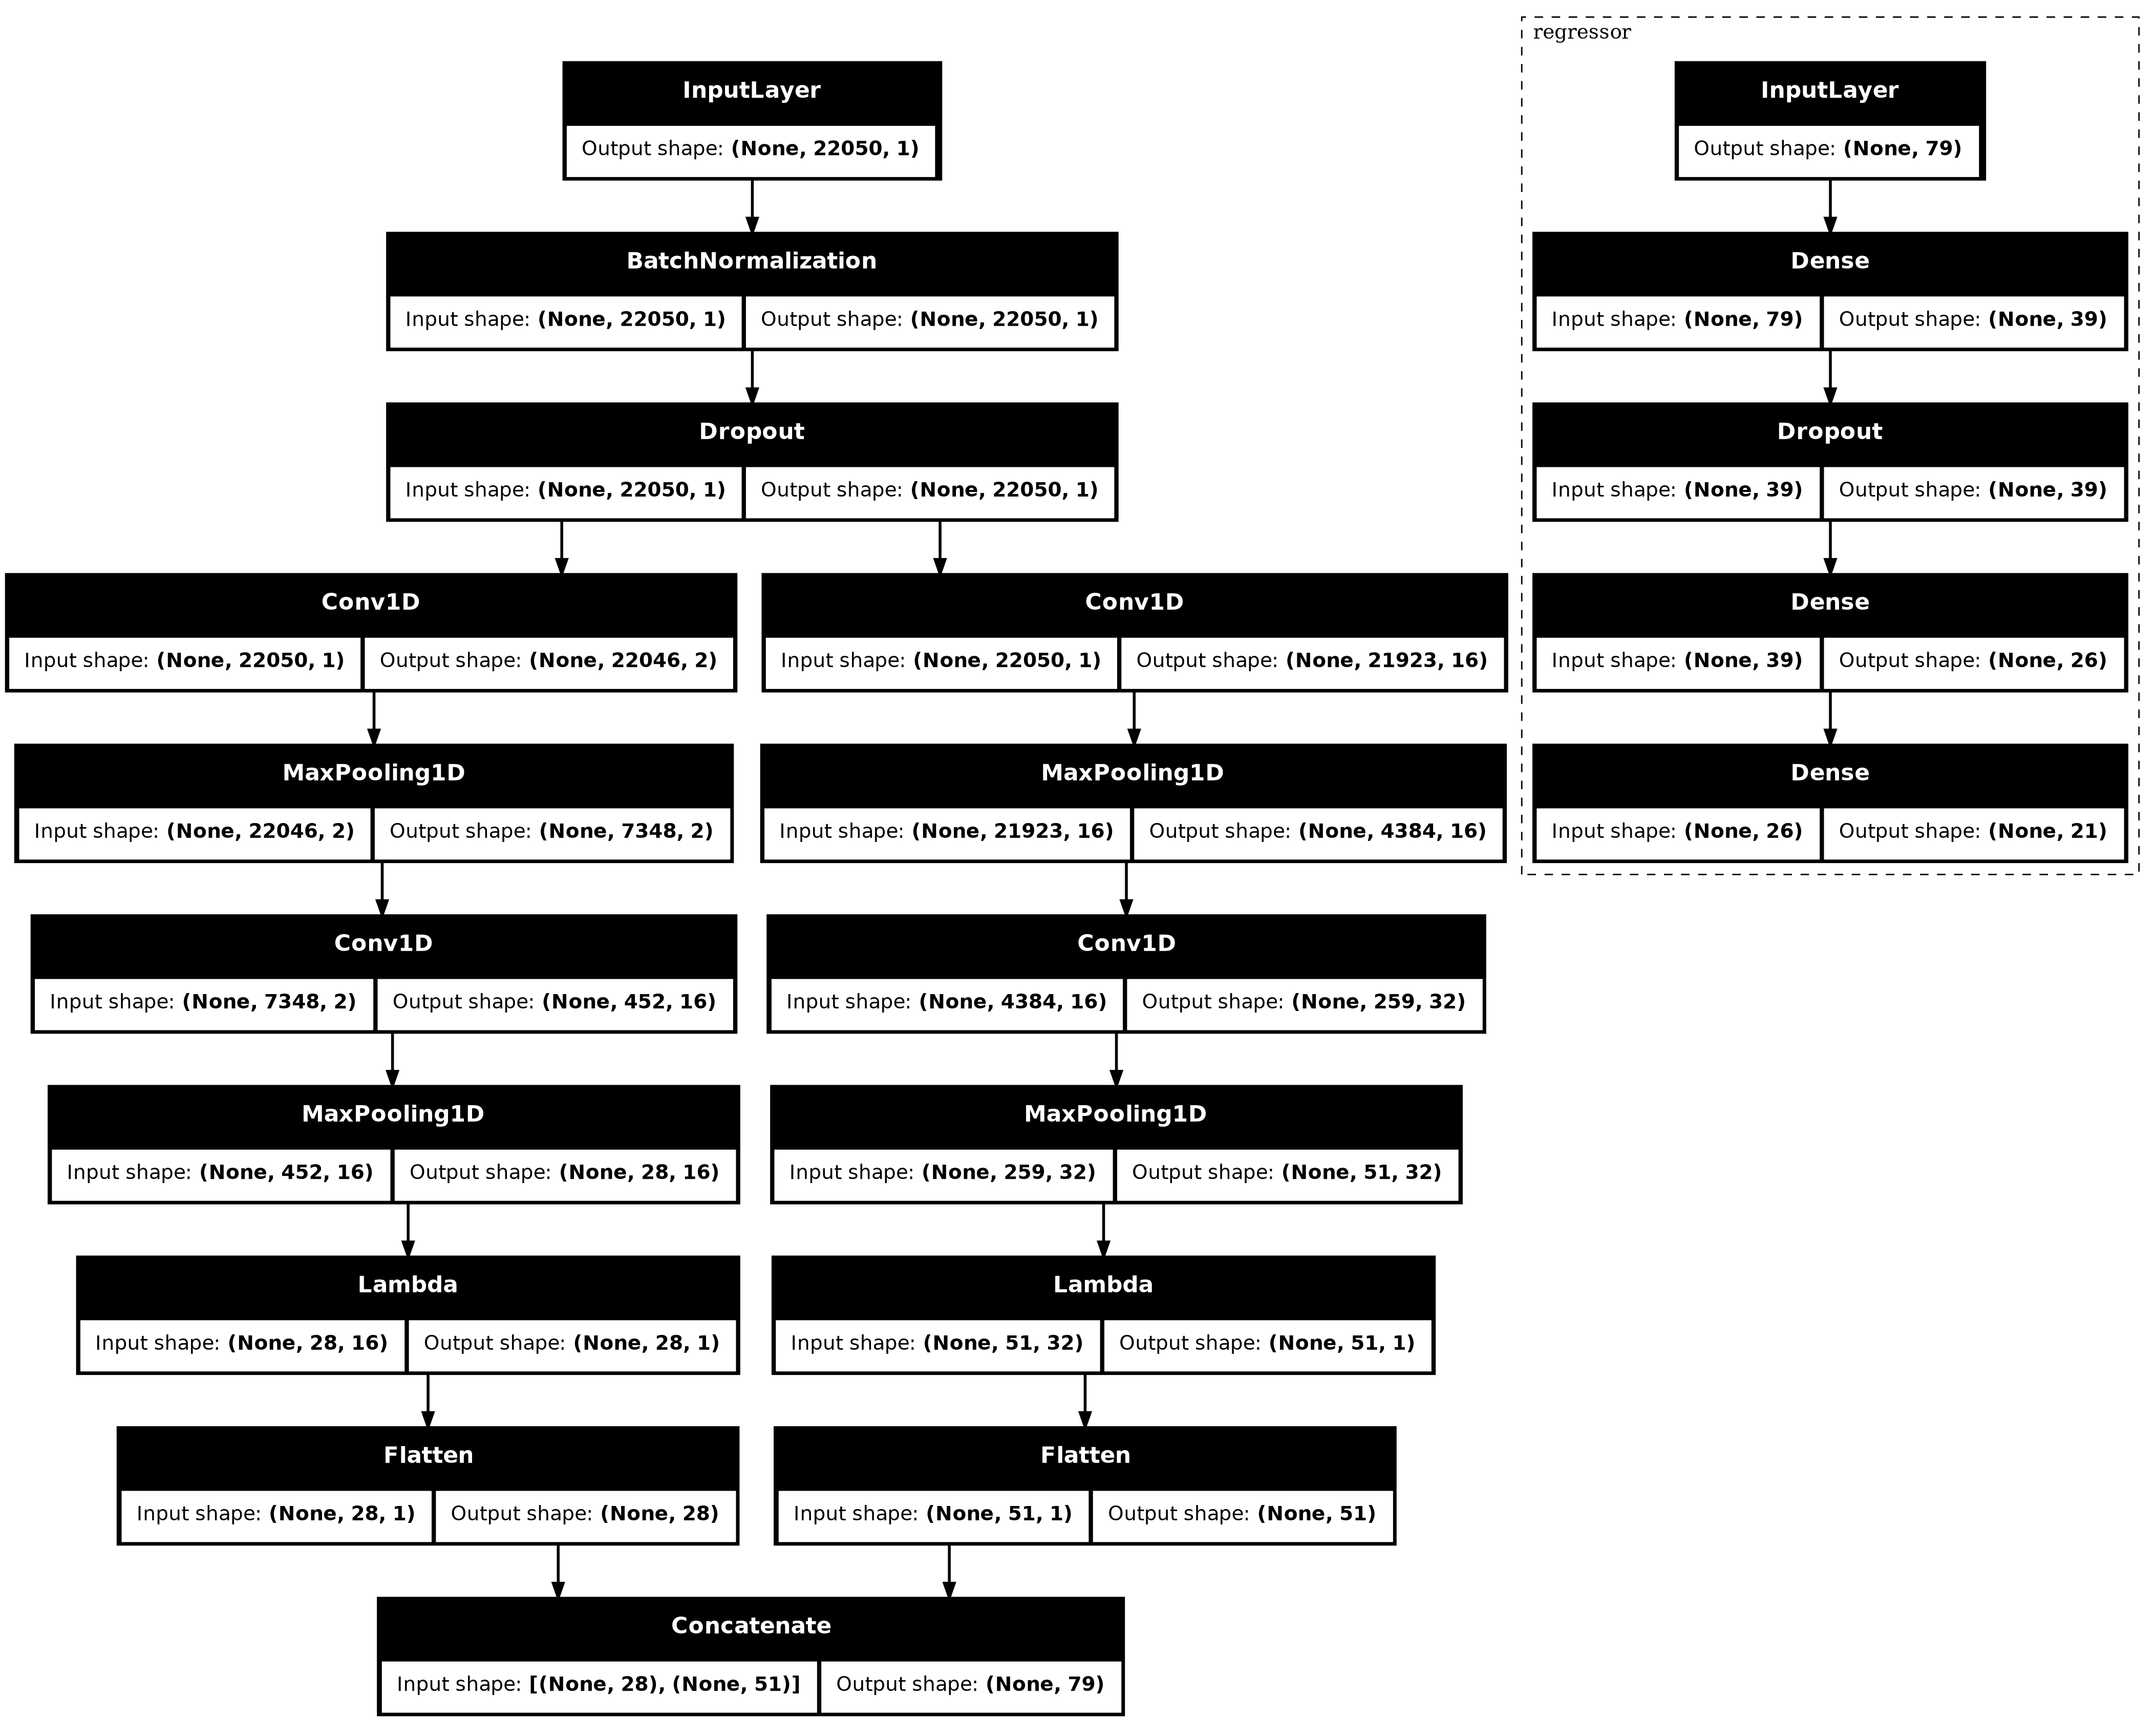

In [74]:
input_len, input_dims, output_dims, activation, bias = x.shape[1], x.shape[2], y_train_norm.shape[1], 'relu', False
  
# Camadas de entrada
input_layer = Input(shape=(input_len, input_dims))

x_n = BatchNormalization()(input_layer)
x_n = Dropout(0.2)(x_n)

# Features 1_1
extrator1_1 = Conv1D(
  filters=2,
  kernel_size=5,
  strides=1,
  activation='relu',
  kernel_regularizer="l1",
  use_bias=True,
)
pooling1_1 = MaxPooling1D(pool_size=3)

features1_1 = extrator1_1(x_n)
features_poll_1_1 = pooling1_1(features1_1)

# Features 1_2
extrator1_2 = Conv1D(
  filters=16,
  kernel_size=128,
  strides=16,
  activation='relu',
  kernel_regularizer="l2",
  use_bias=True,
)
pooling1_2 = MaxPooling1D(pool_size=16)

features1_2 = extrator1_2(features_poll_1_1)
features_poll_1_2 = pooling1_2(features1_2)
features_mean1_2 = Lambda(lambda x: tf.reduce_mean(x, axis=-1, keepdims=True))(features_poll_1_2)

# Features 2_1
extrator2_1 = Conv1D(
  filters=16,
  kernel_size=128,
  strides=1,
  activation='relu',
  kernel_regularizer="l2",
  use_bias=True,
)
pooling2_1 = MaxPooling1D(pool_size=5)

features2_1 = extrator2_1(x_n)
features_poll_2_1 = pooling2_1(features2_1)

# Features 2_2
extrator2_2 = Conv1D(
  filters=32,
  kernel_size=256,
  strides=16,
  activation='relu',
  kernel_regularizer="l2",
  use_bias=True,
)
pooling2_2 = MaxPooling1D(pool_size=5)

features2_2 = extrator2_2(features_poll_2_1)
features_poll_2_2 = pooling2_2(features2_2)
features_mean2_2 = Lambda(lambda x: tf.reduce_mean(x, axis=-1, keepdims=True))(features_poll_2_2)


# Linearizando as features
features_flatten1 = Flatten()(features_mean1_2)
features_flatten2 = Flatten()(features_mean2_2)

# Concatenando as features
features_flatten = Concatenate()([features_flatten1, features_flatten2])

# Montando o regressor
input_dims_regressor = features_flatten.shape[1]

input_layer_regressor = Input(shape=[input_dims_regressor])

x_0 = Dense(int(input_dims_regressor/2), activation=activation, use_bias=bias, kernel_regularizer="l1")(input_layer_regressor)
x_0 = Dropout(0.2)(x_0)
x_2 = Dense(int(input_dims_regressor/3), activation=activation, use_bias=bias)(x_0)
saidas = Dense(output_dims, activation=None, name='regressor_saidas', use_bias=bias, kernel_regularizer="l2")(x_2)

regressao = Model(input_layer_regressor, saidas, name="regressor")

saida = regressao(features_flatten)

model = Model(input_layer, saida, name="regressao")
features = Model(input_layer, features_flatten, name="projecao")

model.compile(optimizer='adamax', loss='mse', metrics=['mae', 'mse', 'mean_absolute_percentage_error'])
plot_model(model, show_shapes=True, expand_nested=True)

In [75]:
# Callback para recuperar o melhor peso, e parar quando ficar três épocas sem melhora
callback = tf.keras.callbacks.EarlyStopping(monitor='loss', patience=5, restore_best_weights=True)

# Treinando o modelo
history = model.fit(x, y_train_norm, epochs=150, validation_split = 0.2, callbacks=[callback])

Epoch 1/150
19/19 ━━━━━━━━━━━━━━━━━━━━ 11s 409ms/step - loss: 4.8853 - mae: 0.8791 - mean_absolute_percentage_error: 113.5723 - mse: 1.0300 - val_loss: 4.3771 - val_mae: 0.8621 - val_mean_absolute_percentage_error: 99.9822 - val_mse: 1.0030
Epoch 2/150
19/19 ━━━━━━━━━━━━━━━━━━━━ 5s 239ms/step - loss: 4.2408 - mae: 0.8700 - mean_absolute_percentage_error: 101.1725 - mse: 1.0059 - val_loss: 3.8385 - val_mae: 0.8621 - val_mean_absolute_percentage_error: 99.9516 - val_mse: 1.0029
Epoch 3/150
19/19 ━━━━━━━━━━━━━━━━━━━━ 5s 240ms/step - loss: 3.7086 - mae: 0.8662 - mean_absolute_percentage_error: 100.7033 - mse: 0.9964 - val_loss: 3.3669 - val_mae: 0.8621 - val_mean_absolute_percentage_error: 99.9005 - val_mse: 1.0029
Epoch 4/150
19/19 ━━━━━━━━━━━━━━━━━━━━ 5s 240ms/step - loss: 3.2461 - mae: 0.8610 - mean_absolute_percentage_error: 100.9727 - mse: 0.9899 - val_loss: 2.9462 - val_mae: 0.8621 - val_mean_absolute_percentage_error: 99.9370 - val_mse: 1.0029
Epoch 5/150
 4/19 ━━━━━━━━━━━━━━━━━━━━ 

KeyboardInterrupt: 

 5/19 ━━━━━━━━━━━━━━━━━━━━ 4s 295ms/step - loss: 2.9390 - mae: 0.8784 - mean_absolute_percentage_error: 100.7842 - mse: 1.0163

In [ ]:
hist = pd.DataFrame(history.history)
hist['epoch'] = history.epoch
hist.tail()

,loss,mae,mean_absolute_percentage_error,mse,val_loss,val_mae,val_mean_absolute_percentage_error,val_mse,epoch
73,0.963856,0.820971,139.027908,0.921483,0.971620,0.814626,123.512215,0.926958,73
74,0.962987,0.819809,117.289246,0.920314,0.973058,0.819339,120.021553,0.932849,74
75,0.961856,0.819565,121.832939,0.919879,0.979576,0.823912,114.493538,0.939265,75
76,0.965948,0.822102,115.384674,0.923187,0.974878,0.817519,120.852074,0.930117,76
77,0.964359,0.821255,115.590042,0.921310,0.979749,0.824750,112.079231,0.940021,77


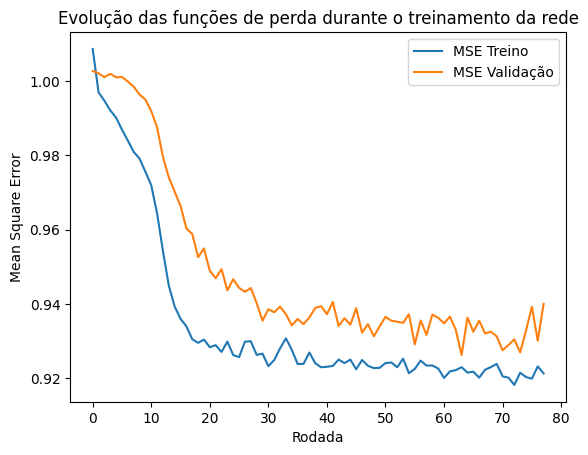

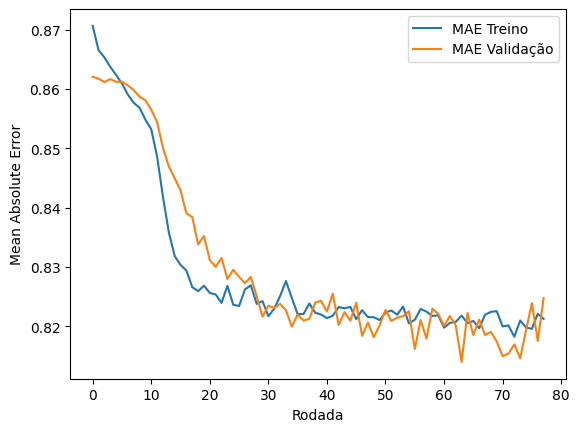

In [ ]:
hist = pd.DataFrame(history.history)
hist['epoch'] = history.epoch

plt.figure()
plt.title("Evolução das funções de perda durante o treinamento da rede")
plt.xlabel('Rodada')
plt.ylabel('Mean Square Error')
plt.plot(hist['epoch'], hist['mse'], label='MSE Treino')
plt.plot(hist['epoch'], hist['val_mse'], label = 'MSE Validação')
plt.legend()

plt.figure()
plt.xlabel('Rodada')
plt.ylabel('Mean Absolute Error')
plt.plot(hist['epoch'], hist['mae'], label='MAE Treino')
plt.plot(hist['epoch'], hist['val_mae'], label = 'MAE Validação')
plt.legend()

plt.show()

## Prevendo a amostra de teste

### Ajustando a base de teste

In [ ]:
x_t = pd.DataFrame(test[0])
x_t.head()

,0
9,"[0.0, 0.000274658203125, 0.0010986328125, 0.00..."
11,"[0.0, -3.0517578125e-05, 3.0517578125e-05, -9...."
19,"[0.0, -3.0517578125e-05, -3.0517578125e-05, 0...."
23,"[0.0, 0.0, -0.00030517578125, 0.00067138671875..."
24,"[0.0, 0.0009765625, 0.00067138671875, -0.00238..."


In [ ]:
x_t = np.array(x_t[0].values.tolist())
x_t[0]

array([0.00000000e+00, 2.74658203e-04, 1.09863281e-03, ...,
       3.05175781e-05, 3.05175781e-05, 0.00000000e+00])

In [ ]:
len(x_t[0])

22050

In [ ]:
y_t = test.drop(columns=[0])
y_t.head()

,frequencia_base,amplitude1,frequency1,beta2,amplitude2,frequency2,beta3,amplitude3,frequency3,beta4,...,frequency4,beta5,amplitude5,frequency5,beta_carrier,amplitude_carrier,attack,decay,sustain,release
9,754.300,0.439,0.130,0.227,0.888,0.341,0.712,0.756,0.583,0.495,...,0.197,0.053,0.912,0.663,0.174,0.721,0.027,0.038,0.083,0.152
11,11311.801,0.522,0.972,0.153,0.246,0.151,0.578,0.137,0.151,0.719,...,0.345,0.559,0.289,0.228,0.414,0.243,0.159,0.077,0.446,0.084
19,18037.688,0.487,0.331,0.963,0.840,0.712,0.086,0.267,0.298,0.299,...,0.636,0.726,0.170,0.599,0.487,0.082,0.188,0.043,0.441,0.049
23,9422.470,0.191,0.071,0.175,0.096,0.089,0.359,0.383,0.495,0.844,...,0.526,0.534,0.844,0.454,0.486,0.413,0.081,0.100,0.284,0.150
24,4144.917,0.688,0.532,0.586,0.917,0.355,0.962,0.175,0.897,0.163,...,0.305,0.673,0.501,0.414,0.974,0.514,0.023,0.091,0.470,0.157


### Chamando o modelo para predição

In [ ]:
y_pred_norm = model.predict(x_t)

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step


In [ ]:
y_pred = scaler_y.inverse_transform(y_pred_norm)

In [ ]:
y_pred = pd.DataFrame(y_pred)
y_pred.head()

,0,1,2,3,4,5,6,7,8,9,...,11,12,13,14,15,16,17,18,19,20
0,10222.027344,0.510880,0.486036,0.504619,0.519243,0.514105,0.513864,0.494263,0.504389,0.485373,...,0.497446,0.516605,0.498098,0.508957,0.481940,0.545817,0.068003,0.051697,0.204027,0.099257
1,10186.624023,0.511243,0.491518,0.514701,0.481192,0.498977,0.486102,0.485123,0.504451,0.499627,...,0.506764,0.510582,0.476606,0.522263,0.490195,0.529967,0.122127,0.049613,0.305620,0.095139
2,10164.698242,0.510557,0.489399,0.511904,0.491494,0.501860,0.492152,0.485494,0.506743,0.497302,...,0.503753,0.511998,0.482666,0.519375,0.490118,0.511325,0.111573,0.050091,0.277005,0.095866
3,10265.255859,0.510522,0.489868,0.510235,0.498556,0.504548,0.497617,0.487465,0.506385,0.491558,...,0.503204,0.515214,0.488428,0.516694,0.486522,0.532099,0.098448,0.051308,0.243096,0.096535
4,10078.712891,0.516409,0.484196,0.507706,0.498764,0.518935,0.519682,0.492351,0.497667,0.490659,...,0.492613,0.519816,0.486742,0.514868,0.469825,0.616035,0.050710,0.044261,0.340387,0.097693


### Calculando erro de teste

In [ ]:
mse = tf.keras.losses.MSE(y_t, y_pred).numpy().mean()
mae = tf.keras.losses.MAE(y_t, y_pred).numpy().mean()
rmse = np.sqrt(mse)

In [ ]:
print(f"RMSE Test: {rmse}")
print(f"MSE Test: {mse}")
print(f"MAE Test: {mae}")

RMSE Test: 1223.762451171875
MSE Test: 1497594.5
MAE Test: 228.78021240234375
